<a href="https://colab.research.google.com/github/Tejaswi5120/ML-LAB/blob/main/Task5/PostLab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Post Lab Task 1**: Classification on Titanic Dataset

/tmp/ipykernel_1800/4156075989.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipykernel_1800/4156075989.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipykernel_1800/4156075989.py:19: FutureWarning: A value is try

Accuracy: 0.7653631284916201

Confusion Matrix:
 [[82 23]
 [19 55]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



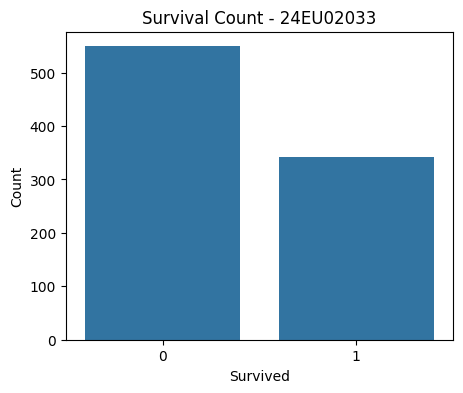

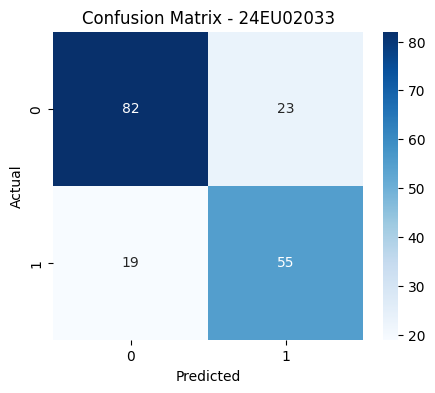

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
titanic = sns.load_dataset('titanic')

# Select useful columns
data = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

# Handle missing values
data['age'].fillna(data['age'].median(), inplace=True)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

# Convert categorical data into numbers
encoder = LabelEncoder()
data['sex'] = encoder.fit_transform(data['sex'])
data['embarked'] = encoder.fit_transform(data['embarked'])

# Features and Target
X = data.drop('survived', axis=1)
y = data['survived']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------- Graph 1 ----------------
plt.figure(figsize=(5,4))
sns.countplot(x='survived', data=data)
plt.title("Survival Count - 24EU02033")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# ---------------- Graph 2 ----------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - 24EU02033")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Post Lab Task 2**: Regression on California Housing Dataset

Mean Absolute Error: 0.533200130495698
Mean Squared Error: 0.5558915986952422
Root Mean Squared Error: 0.7455813830127749
R2 Score: 0.5757877060324524


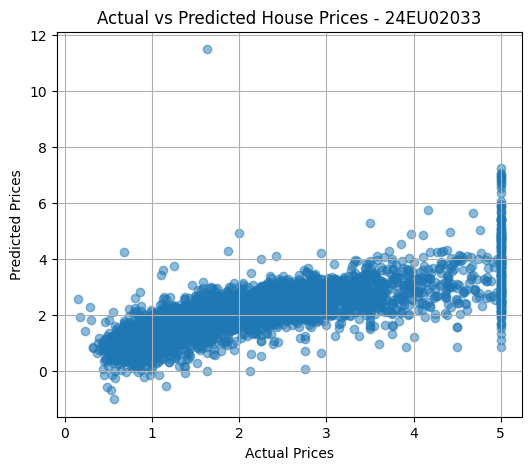

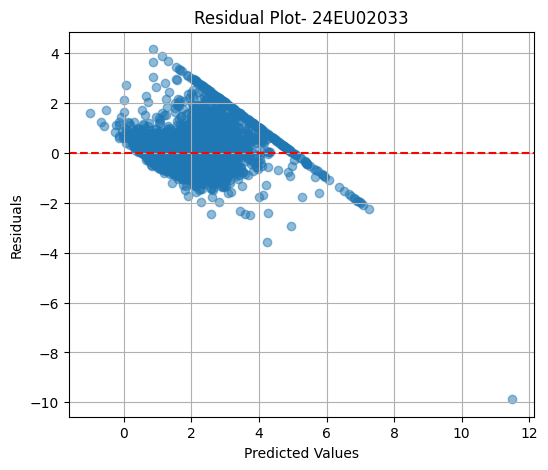

In [2]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# ---------------- Graph 1 ----------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices - 24EU02033")
plt.grid(True)
plt.show()

# ---------------- Graph 2 ----------------
plt.figure(figsize=(6,5))
plt.scatter(y_pred, y_test-y_pred, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot- 24EU02033")
plt.grid(True)
plt.show()